In [15]:
# ================================
# 1. IMPORT
# ================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from IPython.display import Image

In [16]:
# ================================
# 2. SIMULATION SETTINGS
# ================================
dt = 0.1
T_total = 50
time = np.arange(0, T_total, dt)

# Ego vehicle (our car)
x = 0
v = 0

# Lead vehicle (front car)
x_lead = 50
v_lead = 15

In [17]:
# ================================
# 3. PARAMETERS
# ================================
v_ref = 20       # target speed
d0 = 5           # minimum distance
T_gap = 1.5      # time gap

k_v = 0.5        # speed gain
k_d = 0.3        # distance gain

In [18]:
# ================================
# 4. LOGGING
# ================================
x_hist, v_hist, d_hist = [], [], []
mode_hist = []

In [19]:
# ================================
# 5. CONTROLLER
# ================================
def acc_controller(v, v_ref, d, d_safe):
    e_v = v_ref - v
    e_d = d - d_safe
    return k_v * e_v + k_d * e_d

In [20]:
# ================================
# 6. SIMULATION LOOP
# ================================
for t in time:
    # distance to lead car
    d = x_lead - x

    # safe distance
    d_safe = d0 + T_gap * v

    # ---------------------------
    # MODE SWITCHING
    # ---------------------------
    if d > d_safe:
        mode = "Cruise"
        a = k_v * (v_ref - v)
    else:
        mode = "Distance"
        a = acc_controller(v, v_ref, d, d_safe)

    # acceleration limit (realistic)
    a = np.clip(a, -3, 2)

    # update ego vehicle
    v += a * dt
    x += v * dt

    # ---------------------------
    # SCENARIOS
    # ---------------------------
    # Lead car slows down
    if t > 20:
        v_lead = 10

    # Cut-in scenario
    if 25 < t < 27:
        x_lead = x + 20

    # update lead car
    x_lead += v_lead * dt

     # logging
    x_hist.append(x)
    v_hist.append(v)
    d_hist.append(d)
    mode_hist.append(mode)



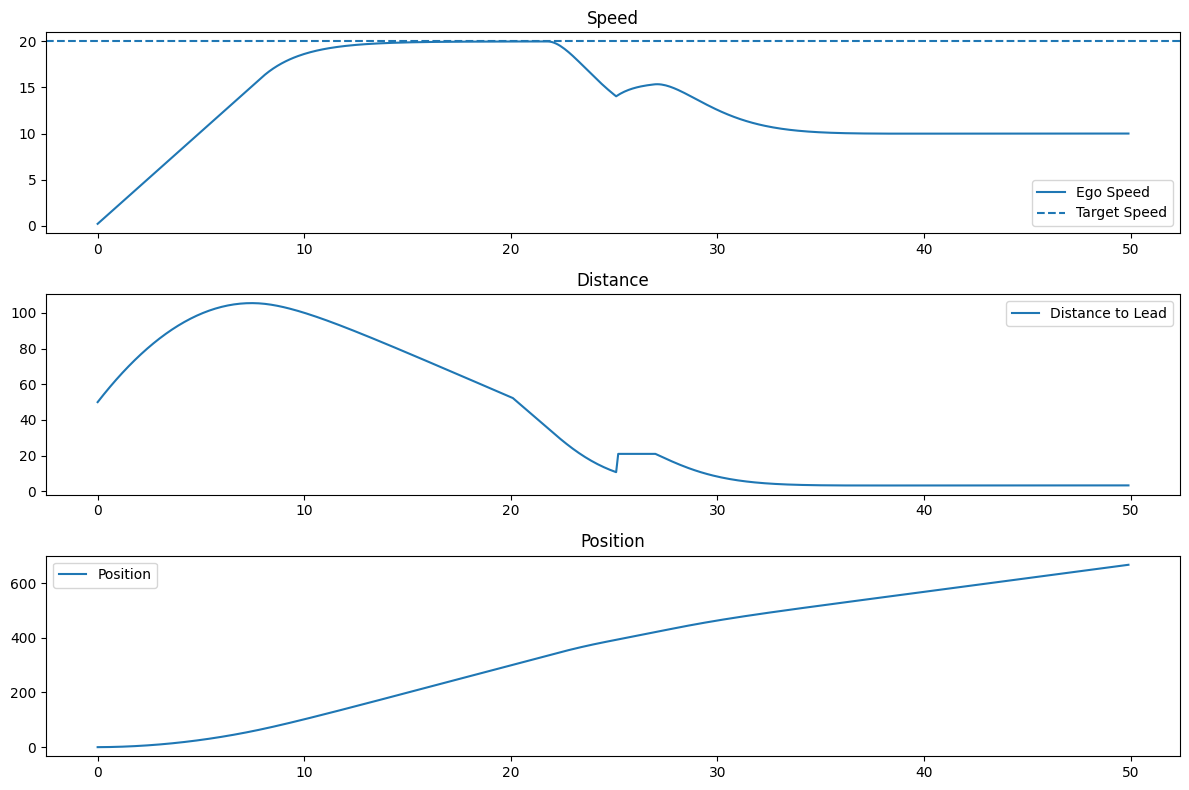

In [22]:
# ================================
# 7. PLOTS
# ================================
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(time, v_hist, label="Ego Speed")
plt.axhline(v_ref, linestyle='--', label="Target Speed")
plt.legend()
plt.title("Speed")

plt.subplot(3,1,2)
plt.plot(time, d_hist, label="Distance to Lead")
plt.legend()
plt.title("Distance")

plt.subplot(3,1,3)
plt.plot(time, x_hist, label="Position")
plt.legend()
plt.title("Position")

plt.tight_layout()
plt.show()

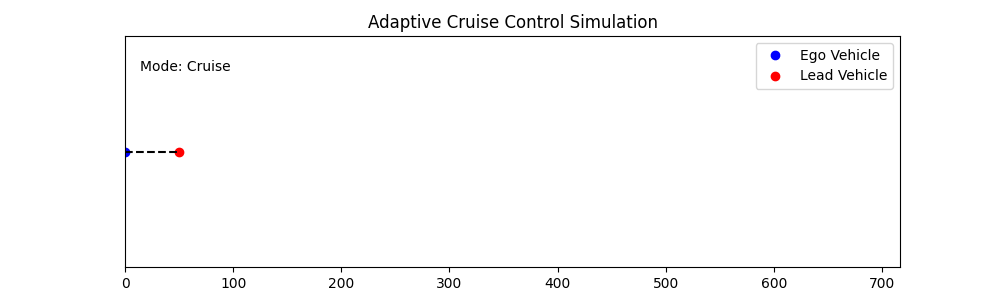

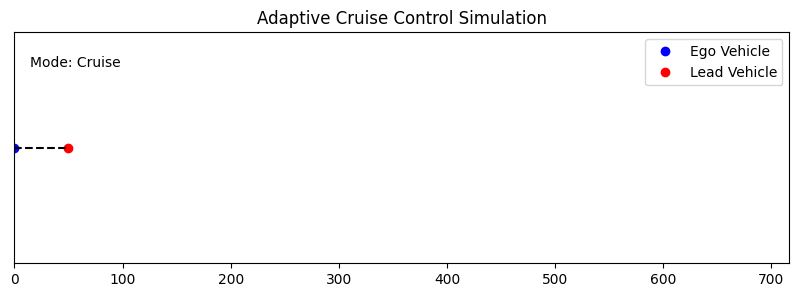

In [24]:
# ================================
# 8. ANIMATION (GIF)
# ================================
fig, ax = plt.subplots(figsize=(10,3))

ego_dot, = ax.plot([], [], 'bo', label='Ego Vehicle')
lead_dot, = ax.plot([], [], 'ro', label='Lead Vehicle')

distance_line, = ax.plot([], [], 'k--')
text = ax.text(0.02, 0.85, '', transform=ax.transAxes)

ax.set_xlim(0, max(x_hist)+50)
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_title("Adaptive Cruise Control Simulation")
ax.legend()

def update(frame):
    ego_x = x_hist[frame]
    lead_x = x_hist[frame] + d_hist[frame]

    ego_dot.set_data([ego_x], [0])
    lead_dot.set_data([lead_x], [0])

    # distance line
    distance_line.set_data([ego_x, lead_x], [0, 0])

    text.set_text(f"Mode: {mode_hist[frame]}")

    return ego_dot, lead_dot, distance_line, text

ani = animation.FuncAnimation(fig, update, frames=len(x_hist), interval=50)

# save GIF
ani.save("acc_simulation.gif", writer=PillowWriter(fps=20))

# display GIF
Image(filename="acc_simulation.gif")